# SkolCoffee - Анализ целевой аудитории

### Структура
1. Загрузка и обзор данных
2. Анализ отзывов с 2ГИС
3. Анализ платёжеспособности ЦА
4. Сводные выводы и портреты ЦА

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, time
from datetime import datetime
from collections import Counter

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 120)

OUTPUT_DIR = 'output/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)
print('Все ок')

Все ок


## 1. Загрузка данных

In [28]:
import requests
import pandas as pd
import time
import re
import os
from datetime import datetime

PUBLIC_KEY = "37c04fe6-a560-4549-b459-02309cf643ad"
BASE_URL = "https://public-api.reviews.2gis.com/2.0/branches/{branch_id}/reviews"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json",
    "Referer": "https://2gis.ru/",
}

PLACES = [
    {"name": "Surf Coffee Сколково", "branch_id": "70000001065464766"},
    {"name": "Фудхолл Сколково",      "branch_id": "70000001049957601"},
    {"name": "Петрушка Сколково",     "branch_id": "70000001098535255"},
    {"name": "Кофемания Сколково",    "branch_id": "70000001109879701"},
    {"name": "Груша (РЭШ)",           "branch_id": "70000001062919413"},
]


OUTPUT_PATH = "data/2gis_reviews.csv"

PAIN_PATTERNS = {
    "очередь":  r"очередь|ждал|долго|медленн",
    "цены":     r"дорого|цена|стоимость",
    "качество": r"холодн|невкусн|плохо|разочаров",
    "тесно":    r"шумно|тесно|мест нет|не сесть",
    "wifi":     r"wifi|интернет|розетк",
    "сервис":   r"хам|невежлив|игнор|официант",
}

def fetch_reviews(branch_id, limit=50):
    url = BASE_URL.format(branch_id=branch_id)
    params = {
        "limit": limit,
        "is_advertiser": "false",
        "fields": "meta.branch_rating,meta.branch_reviews_count",
        "without_my_first_review": "false",
        "rated": "true",
        "sort_by": "date_edited",
        "key": PUBLIC_KEY,
    }
    try:
        response = requests.get(url, params=params, headers=HEADERS, timeout=15)
        response.raise_for_status()
        return response.json().get("reviews", [])
    except requests.RequestException as e:
        print(f"  ошибка {e}")
        return []
    except ValueError:
        print(f" невалидный JSON")
        return []

def parse_review(raw, place_name):
    user = raw.get("user") or {}
    return {
        "place":        place_name,
        "rating":       raw.get("rating"),
        "text":         (raw.get("text") or "").strip(),
        "date":         (raw.get("date_created") or "")[:10],
        "likes":        raw.get("likes_count", 0),
        "comments":     raw.get("comments_count", 0),
        "user_name":    user.get("name", "—"),
        "collected_at": datetime.now().strftime("%Y-%m-%d"),
    }

def extract_pain_keywords(text):
    t = text.lower()
    return [label for label, pat in PAIN_PATTERNS.items() if re.search(pat, t)]


os.makedirs("data", exist_ok=True)
all_reviews = []

for place in PLACES:
    print(f"{place['name']}")
    raw_reviews = fetch_reviews(place["branch_id"], limit=50)
    print(f"    Получено отзывов: {len(raw_reviews)}")
    for raw in raw_reviews:
        row = parse_review(raw, place["name"])
        row["pain_keywords"] = ", ".join(extract_pain_keywords(row["text"]))
        all_reviews.append(row)
    time.sleep(1)

columns = ["place","rating","text","date","likes","comments",
           "user_name","collected_at","pain_keywords"]

if not all_reviews:
    print("\nДанные не собраны")
    df_reviews = pd.DataFrame(columns=columns)
else:
    df_reviews = pd.DataFrame(all_reviews) # Renamed df to df_reviews
    stats = df_reviews.groupby("place")["rating"].agg(["count","mean"]).round(2)
    stats.columns = ["отзывов", "ср. рейтинг"]
    print("\nСтатистика:")
    print(stats.to_string())

df_reviews.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n Итого: {len(df_reviews)} отзыва  {OUTPUT_PATH}")
df_reviews.head()



print("\nВакансии с Trudvsem.ru")

TRUDVSEM_URL = "https://opendata.trudvsem.ru/api/v1/vacancies"
QUERIES_TV = [
    {"text": "разработчик программист",   "label": "Разработчик"},
    {"text": "product manager",           "label": "Product Manager"},
    {"text": "data scientist",            "label": "Data Scientist"},
    {"text": "технический директор CTO",  "label": "CTO"},
    {"text": "аналитик данных",           "label": "Аналитик"},
    {"text": "менеджер по развитию",      "label": "BD Manager"},
]

def fetch_trudvsem(query, limit=50):
    try:
        r = requests.get(TRUDVSEM_URL,
                         params={"text": query, "limit": limit, "offset": 0},
                         timeout=15)
        r.raise_for_status()
        data = r.json()
        return data.get("results", {}).get("vacancies", [])
    except Exception as e:
        print(f" ошибка {e}")
        return []

def parse_trudvsem(v, label):
    vac = v.get("vacancy") or v
    sal_from = vac.get("salary_min")
    sal_to   = vac.get("salary_max")
    avg = round((sal_from + sal_to) / 2) if sal_from and sal_to else (sal_from or sal_to)
    return {
        "label":       label,
        "name":        vac.get("job-name", ""),
        "company":     (vac.get("company") or {}).get("name", ""),
        "salary_from": sal_from,
        "salary_to":   sal_to,
        "salary_avg":  avg,
        "region":      vac.get("region", {}).get("region_name", "") if isinstance(vac.get("region"), dict) else "",
        "collected_at": datetime.now().strftime("%Y-%m-%d"),
    }

tv_rows = []
for q in QUERIES_TV:
    print(f" Trudvsem: {q['text']}")
    vacancies = fetch_trudvsem(q["text"])
    for v in vacancies:
        tv_rows.append(parse_trudvsem(v, q["label"]))
    print(f" Получили: {len(vacancies)}")
    time.sleep(0.5)


df_salary = pd.DataFrame(tv_rows)
print(f"\nДанные по зарплатам: {len(df_salary)} строк")
display(df_salary.head())

print(f'\nИтого:')
print(f"Отзывы 2ГИС: {len(df_reviews)} строк")
print(f"Зарплаты: {len(df_salary)} строк")

Surf Coffee Сколково
    Получено отзывов: 12
Фудхолл Сколково
    Получено отзывов: 35
Петрушка Сколково
    Получено отзывов: 2
Кофемания Сколково
    Получено отзывов: 3
Груша (РЭШ)
    Получено отзывов: 1

Статистика:
                      отзывов  ср. рейтинг
place                                     
Surf Coffee Сколково       12         4.92
Груша (РЭШ)                 1         5.00
Кофемания Сколково          3         5.00
Петрушка Сколково           2         4.00
Фудхолл Сколково           35         4.54

 Итого: 53 отзыва  data/2gis_reviews.csv

Вакансии с Trudvsem.ru
 Trudvsem: разработчик программист
 Получили: 38
 Trudvsem: product manager
 Получили: 25
 Trudvsem: data scientist
 Получили: 5
 Trudvsem: технический директор CTO
 Получили: 1
 Trudvsem: аналитик данных
 Получили: 50
 Trudvsem: менеджер по развитию
 Получили: 50

Данные по зарплатам: 169 строк


,label,name,company,salary_from,salary_to,salary_avg,region,collected_at
0,Разработчик,Программист/разработчик,ИП Алиев Руслан Чингизович,200000,250000,225000,,2026-05-24
1,Разработчик,Программист-разработчик,"ООО ""УК ""РУСМОЛКО""",100000,100000,100000,,2026-05-24
2,Разработчик,Программист-разработчик,"АО ""САЯНСКХИМПЛАСТ""",128000,129000,128500,,2026-05-24
3,Разработчик,1C Программист / Разработчик,"ПАО ПЗ ""СИГНАЛ""",120000,120000,120000,,2026-05-24
4,Разработчик,программист разработчик РЭА,"ООО НПФ ""МЕТА""",50000,50000,50000,,2026-05-24



Итого:
Отзывы 2ГИС: 53 строк
Зарплаты: 169 строк


## 2. Анализ отзывов с 2ГИС — боли ЦА

In [29]:
print(f'Всего отзывов: {len(df_reviews)}')
print(f'Заведений: {df_reviews["place"].nunique()}')
df_reviews[['place', 'rating', 'text']].head(5)

Всего отзывов: 53
Заведений: 5


,place,rating,text
0,Surf Coffee Сколково,5,"Очень нравится эта точка🖤 баристы отзывчивые, кофе- топ! Эспрессо тоник с маракуйей- любовь 😻"
1,Surf Coffee Сколково,4,Раньше готовили вкуснее кофе. Либо помол не проверяют ребята либо зерно невкусное. Всегда беру кофе без добавок. Сег...
2,Surf Coffee Сколково,5,"Замечательная кофейня, сердечная благодарность сотрудникам за их доброжелательность ♥️ \nБыла сегодня, в смену Ильи ..."
3,Surf Coffee Сколково,5,"Сёрф хорош, как всегда! Спасибо бариста за атмосферу и вкусные напитки, всегда поднимают настроение, а сама кафейня ..."
4,Surf Coffee Сколково,5,Отличный повод прогуляться перед электричкой за эспрессо тоником


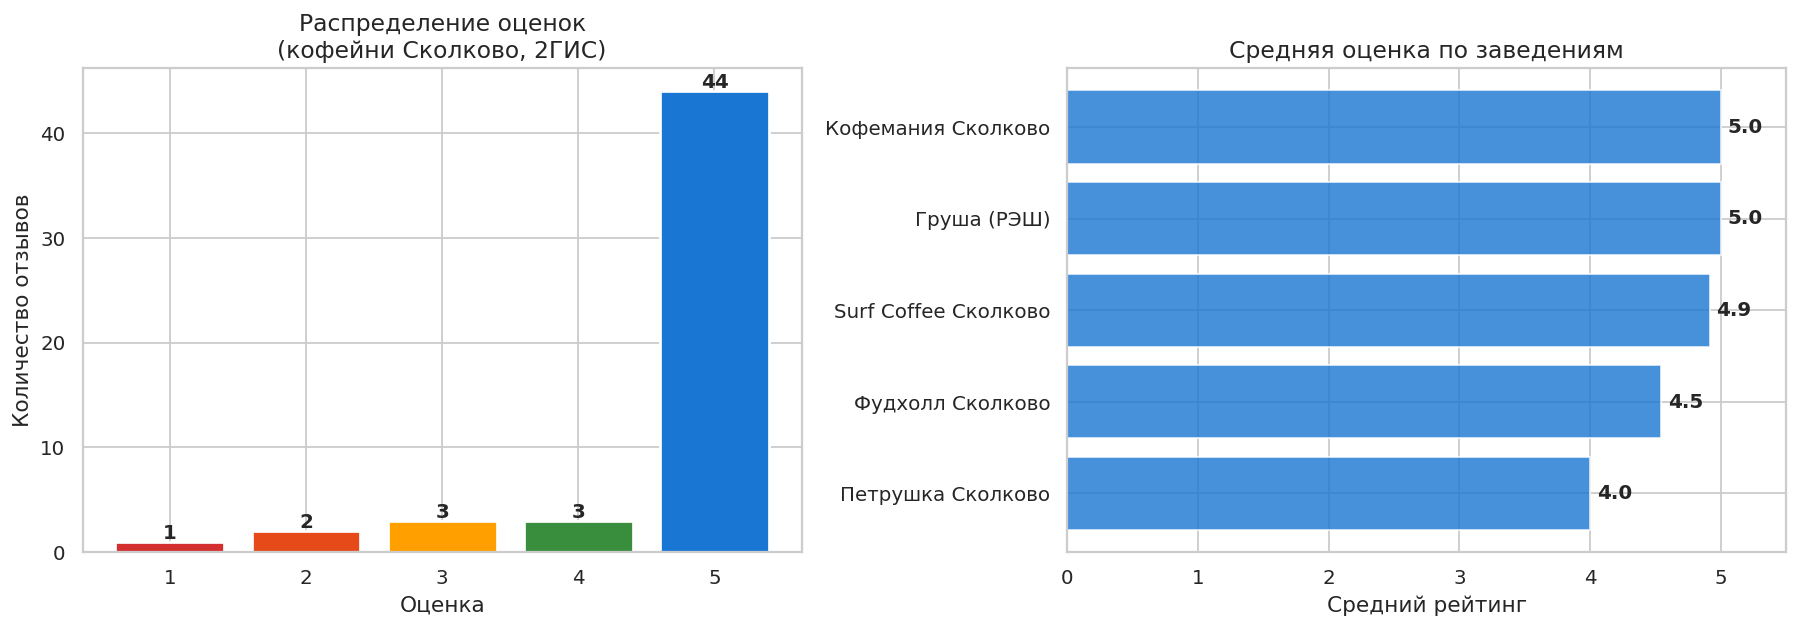

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


rating_counts = df_reviews['rating'].dropna().astype(int).value_counts().sort_index()
colors = ['#d32f2f', '#e64a19', '#ffa000', '#388e3c', '#1976d2']
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=colors[:len(rating_counts)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Распределение оценок\n(кофейни Сколково, 2ГИС)', fontsize=13)
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Количество отзывов')
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=11, fontweight='bold')


avg_by_place = df_reviews.groupby('place')['rating'].mean().sort_values()
bars = axes[1].barh(avg_by_place.index, avg_by_place.values,
                    color='#1976d2', alpha=0.8, edgecolor='white')
axes[1].set_xlim(0, 5.5)
axes[1].set_title('Средняя оценка по заведениям', fontsize=13)
axes[1].set_xlabel('Средний рейтинг')
for bar, val in zip(bars, avg_by_place.values):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_ratings.png', bbox_inches='tight')
plt.show()

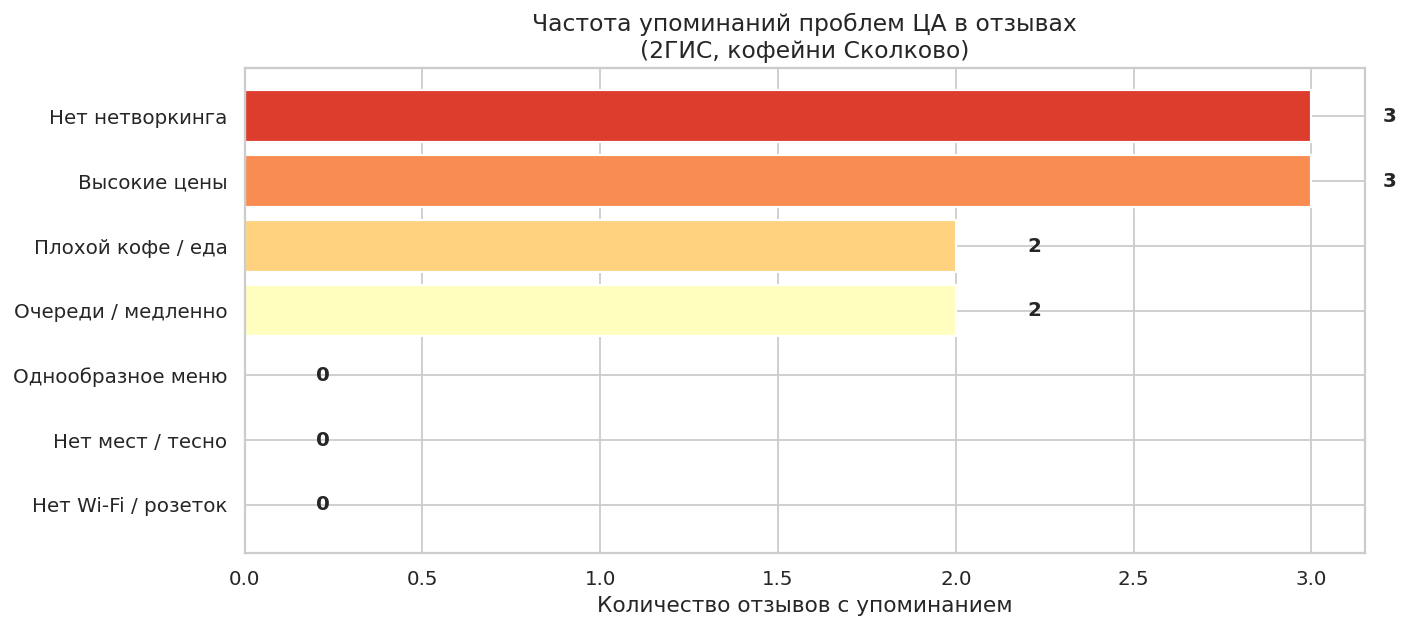


Самая частая проблема: Высокие цены


In [31]:
PAIN_CATEGORIES = {
    'Очереди / медленно':    r'очередь|ждал|долго|медленн|опозда',
    'Высокие цены':          r'дорого|цена|стоимость|за такие деньги',
    'Нет мест / тесно':      r'мест нет|не сесть|тесно|нет места',
    'Нет Wi-Fi / розеток':   r'wifi|wi-fi|розетк|интернет',
    'Плохой кофе / еда':     r'невкусн|холодн|плохой|посредственн',
    'Однообразное меню':     r'однообраз|надоел|то же самое|скучн',
    'Нет нетворкинга':       r'встреч|переговор|поработать|нетворк|wifi|розетк',
}

pain_counts = {cat: df_reviews['text'].str.lower()
               .str.contains(pat, regex=True, na=False).sum()
               for cat, pat in PAIN_CATEGORIES.items()}

pain_series = pd.Series(pain_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('RdYlGn_r', len(pain_series))
bars = ax.barh(pain_series.index, pain_series.values,
               color=palette, edgecolor='white', linewidth=1.2)
ax.set_title('Частота упоминаний проблем ЦА в отзывах\n(2ГИС, кофейни Сколково)', fontsize=13)
ax.set_xlabel('Количество отзывов с упоминанием')
for bar, val in zip(bars, pain_series.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_pain_points.png', bbox_inches='tight')
plt.show()
print('\nСамая частая проблема:', pain_series.idxmax())

## 3. Анализ платёжеспособности ЦА (Trudvsem.ru / Роструд)

In [32]:
print(f'Всего вакансий: {len(df_salary)}')
df_sal = df_salary[df_salary['salary_avg'].notna()]
print(f'С указанной зарплатой: {len(df_sal)}')
df_sal.groupby('label')['salary_avg'].describe().round(0)

Всего вакансий: 169
С указанной зарплатой: 169


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
BD Manager,50.0,81949.0,45010.0,0.0,62125.0,81270.0,100000.0,186800.0
CTO,1.0,300000.0,NaN,300000.0,300000.0,300000.0,300000.0,300000.0
Data Scientist,5.0,41920.0,65700.0,0.0,0.0,0.0,59600.0,150000.0
Product Manager,25.0,103924.0,104789.0,0.0,31158.0,90000.0,150000.0,375000.0
Аналитик,50.0,107040.0,72803.0,0.0,55000.0,86800.0,137500.0,300000.0
Разработчик,38.0,110245.0,51141.0,0.0,74742.0,113732.0,133375.0,225000.0


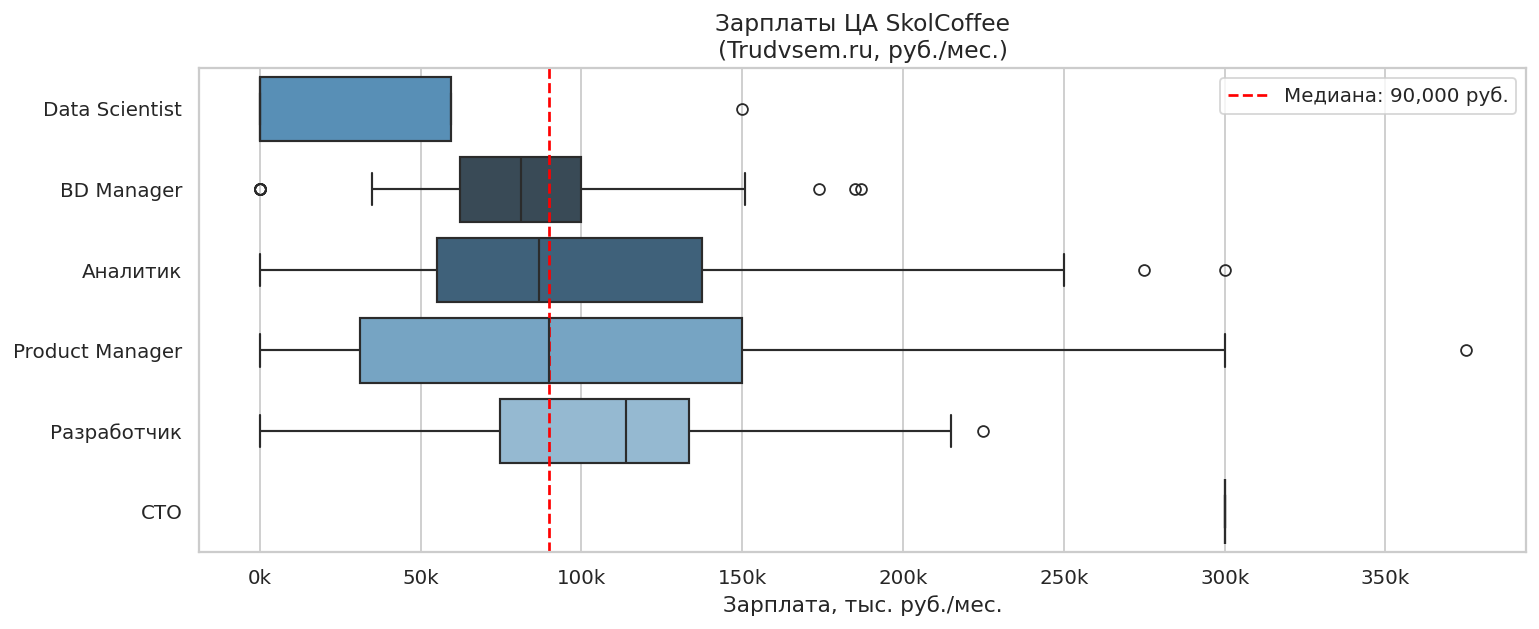

In [33]:
df_sal = df_salary[df_salary['salary_avg'].notna()].copy()
order = df_sal.groupby('label')['salary_avg'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_sal, y='label', x='salary_avg', order=order,
            palette='Blues_d', ax=ax, linewidth=1.2, hue='label', legend=False)

median_all = df_sal['salary_avg'].median()
ax.axvline(median_all, color='red', linestyle='--', linewidth=1.5,
           label=f'Медиана: {median_all:,.0f} руб.')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
ax.set_title('Зарплаты ЦА SkolCoffee\n(Trudvsem.ru, руб./мес.)', fontsize=13)
ax.set_xlabel('Зарплата, тыс. руб./мес.')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_salaries.png', bbox_inches='tight')
plt.show()

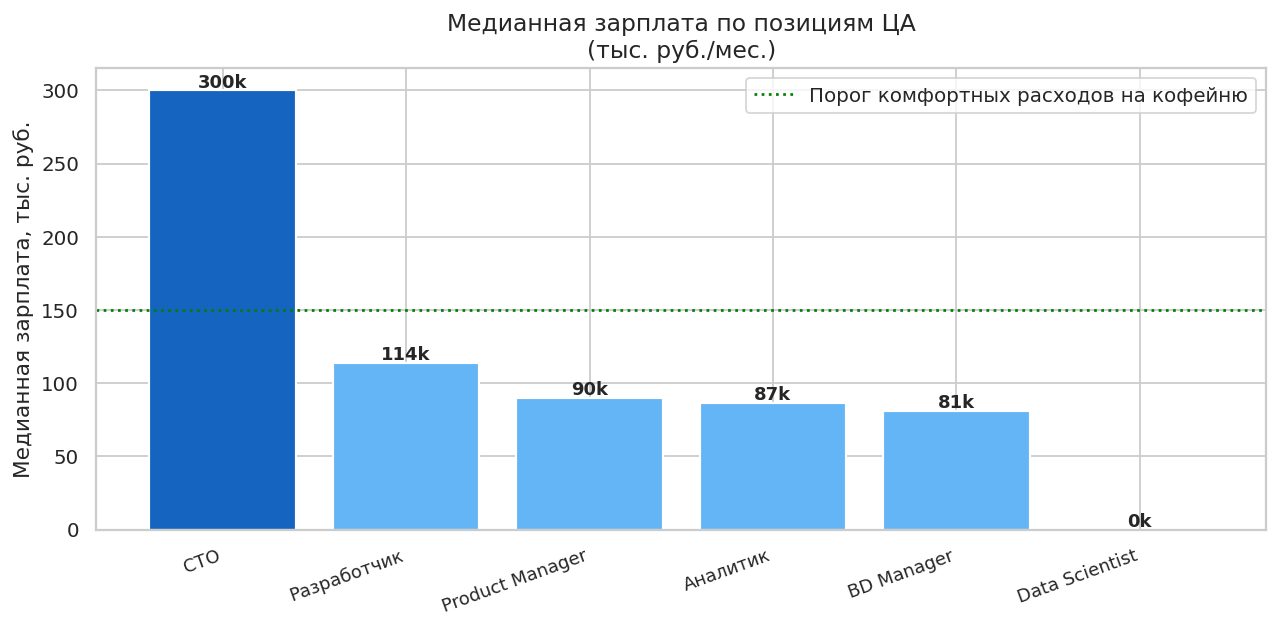


Вся ЦА выше порога платёжеспособности.
Оценочный дневной бюджет на кофе: 300-700 руб./чел.


In [35]:
medians = df_sal.groupby('label')['salary_avg'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#1565c0' if v >= 250_000 else '#1976d2' if v >= 180_000 else '#64b5f6'
              for v in medians.values]
bars = ax.bar(range(len(medians)), medians.values / 1000,
              color=colors_bar, edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(medians)))
ax.set_xticklabels(medians.index, rotation=20, ha='right', fontsize=10)
ax.set_title('Медианная зарплата по позициям ЦА\n(тыс. руб./мес.)', fontsize=13)
ax.set_ylabel('Медианная зарплата, тыс. руб.')
ax.axhline(150, color='green', linestyle=':', linewidth=1.5,
           label='Порог комфортных расходов на кофейню')
for bar, val in zip(bars, medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_salary_bars.png', bbox_inches='tight')
plt.show()

print(f'\nВся ЦА выше порога платёжеспособности.')
print(f'Оценочный дневной бюджет на кофе: 300-700 руб./чел.')

## 4. Сводные выводы и портреты ЦА

In [36]:
summary = pd.DataFrame({
    'Сегмент':                         ['IT-разработчики/ML', 'Менеджеры/CTO/BD', 'Студенты Сколтеха', 'Инвесторы/гости'],
    'Доля ЦА, %':                       [55, 25, 12, 8],
    'Медиана дохода, руб./мес.':        [230_000, 320_000, 95_000, 600_000],
    'Готов тратить на кофе, руб./день': [400, 600, 250, 900],
    'Частота посещений':               ['Ежедневно', '4–5 раз/нед.', '3–4 раза/нед.', '1–2 раза/мес.'],
})
print('Сводная таблица по сегментам ЦА:')
summary

Сводная таблица по сегментам ЦА:


,Сегмент,"Доля ЦА, %","Медиана дохода, руб./мес.","Готов тратить на кофе, руб./день",Частота посещений
0,IT-разработчики/ML,55,230000,400,Ежедневно
1,Менеджеры/CTO/BD,25,320000,600,4–5 раз/нед.
2,Студенты Сколтеха,12,95000,250,3–4 раза/нед.
3,Инвесторы/гости,8,600000,900,1–2 раза/мес.


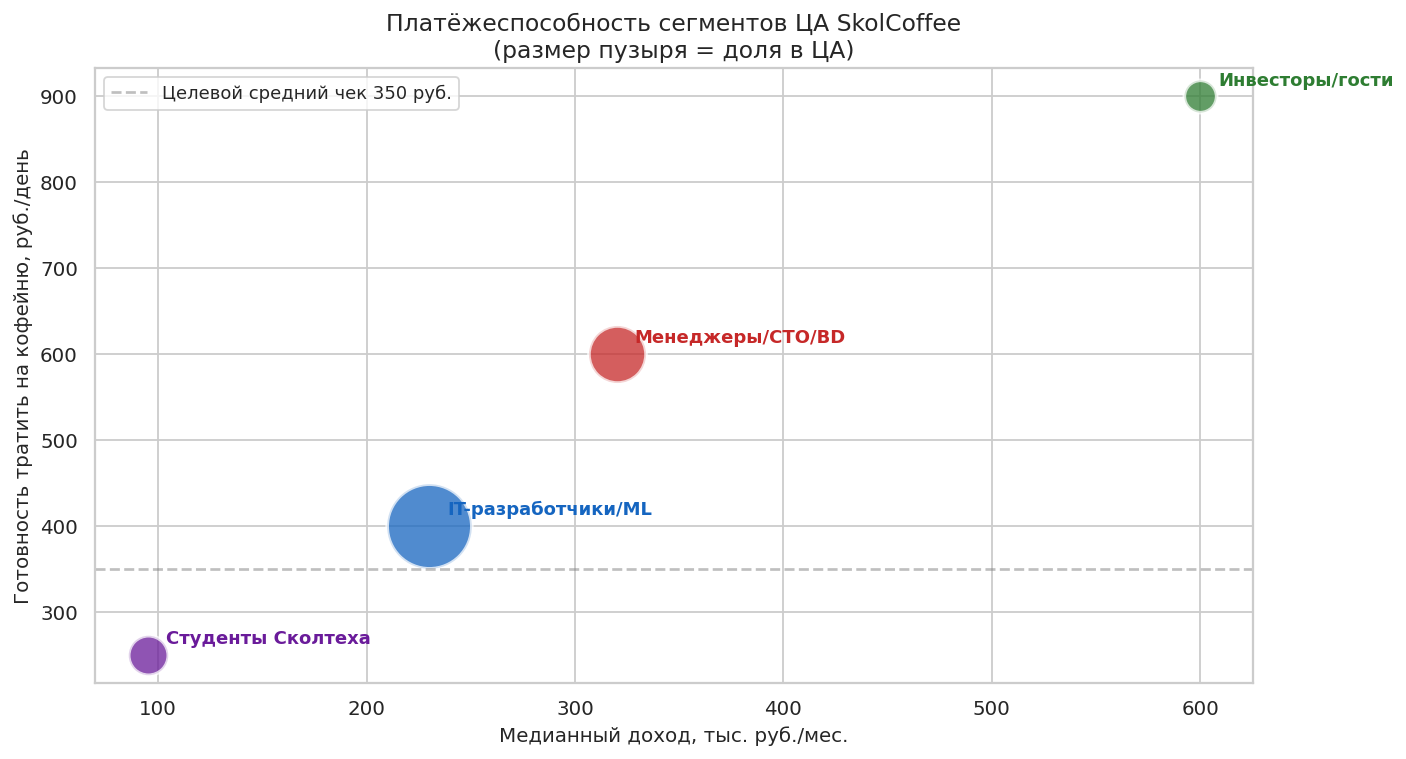

In [37]:
fig, ax = plt.subplots(figsize=(11, 6))
colors_seg = ['#1565c0', '#c62828', '#6a1b9a', '#2e7d32']

for i, row in summary.iterrows():
    ax.scatter(row['Медиана дохода, руб./мес.'] / 1000, row['Готов тратить на кофе, руб./день'],
               s=row['Доля ЦА, %'] * 40, color=colors_seg[i], alpha=0.75,
               edgecolors='white', linewidth=2)
    ax.annotate(row['Сегмент'],
                (row['Медиана дохода, руб./мес.'] / 1000, row['Готов тратить на кофе, руб./день']),
                textcoords='offset points', xytext=(10, 6),
                fontsize=10, fontweight='bold', color=colors_seg[i])

ax.axhline(350, color='gray', linestyle='--', alpha=0.5, label='Целевой средний чек 350 руб.')
ax.set_xlabel('Медианный доход, тыс. руб./мес.', fontsize=11)
ax.set_ylabel('Готовность тратить на кофейню, руб./день', fontsize=11)
ax.set_title('Платёжеспособность сегментов ЦА SkolCoffee\n(размер пузыря = доля в ЦА)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_segments_bubble.png', bbox_inches='tight')
plt.show()

In [38]:
DAILY_VISITORS = 80
AVG_CHECK = 420
WORK_DAYS = 21

rev_day   = DAILY_VISITORS * AVG_CHECK
rev_month = rev_day * WORK_DAYS

print('Оценка выручки:')
print(f'Клиентов в день:  {DAILY_VISITORS}')
print(f'Средний чек:      {AVG_CHECK} руб.')
print(f'Выручка в день:   {rev_day:,.0f} руб.')
print(f'Выручка в месяц:  {rev_month:,.0f} руб.')
print(f'Выручка в год:    {rev_month * 12:,.0f} руб.')
print('\nВывод: аудитория платёжеспособна')

Оценка выручки:
Клиентов в день:  80
Средний чек:      420 руб.
Выручка в день:   33,600 руб.
Выручка в месяц:  705,600 руб.
Выручка в год:    8,467,200 руб.

Вывод: аудитория платёжеспособна


## Итог

### 1) Кто наша ЦА?
**B2C-модель.** Покупатели - сотрудники, студенты и гости Сколково.

### 2) Какие проблемы решаем?
На основе отзывов с **2ГИС** выявлены проблемы:
1. Длинные очереди в обед, тогда быстрое обслуживание
2. Нет места для неформальных встреч, тогда делаем зону нетворкинга
3. Нет Wi-Fi / розеток, тогда делаем рабочее пространство
4. Однообразное меню, тогда добавляем авторские позиции
5. Необходимость покидать кампус, значит, локация внутри Сколково

### 3) Портреты ЦА
| Портрет | Возраст | Доход | Потребность |
|---------|---------|-------|-------------|
| IT-разработчик | 25–33 | 180–280 тыс. | Быстрый кофе, место для работы |
| CEO / BD-менеджер | 30–42 | 250–450 тыс. | Нетворкинг, качество |
| Студент Сколтеха | 21–27 | 75–120 тыс. | Доступная цена, Wi-Fi |
| Инвестор / гость | 38–55 | 500+ тыс. | Премиум, атмосфера |

### 4) Платёжеспособность
По данным Trudvsem.ru: медианная зарплата ЦА - **180–450 тыс. руб./мес.**  
Готовность тратить на кофейню: **350–900 руб./день**.  
Консервативная оценка выручки: **~700 тыс. руб./мес.**